# FCC-ee Impedance/Wake Model: Longitudinal Impedance $Z_{z}$ ($\Omega$)

## Import dependencies

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import os
from pathlib import Path
import matplotlib.patches as mpatches
from matplotlib.ticker import LogLocator
import matplotlib.ticker as ticker

## Multiplicative factors for elements with the same model

In [ ]:
N_tot_bellows=10000 
N_tot_BPM=10000  
N_tot_cavities=132
N_tot_RF_tapers=33

## Input and output folders

In [3]:
project_root   = Path.cwd().parent 
element_folder = project_root / "elements"
image_folder   = project_root / "images" / "coll_square" / "taper_H15_V2.5" / "imp"
output_folder  = project_root / "output" / "coll_square" / "taper_H15_V2.5" / "imp"

# crea solo dove serve scrivere
os.makedirs(image_folder, exist_ok=True)
os.makedirs(output_folder, exist_ok=True)


## Upload elements data

In [ ]:
# Bellows
Z_bellow = np.loadtxt(element_folder / "bellows" / "imp" / "Bellows_Z_long_04mm.txt", skiprows=0)

# BPM 
Z_BPM=np.loadtxt(element_folder / "BPMs" / "imp" / "BPMs_Zz_200mm.txt",skiprows=0)   

# RF cavities
Z_cavity=np.loadtxt(element_folder / "RF_cavity" / "imp" / "RF_cavity_400MHz_Zlong_FFT_wake.txt",skiprows=0)

# tapers
Z_taper_in=np.loadtxt(element_folder / "tapers" / "imp" / "taper_in_Z_0.4_mm_long.txt",skiprows=1)
Z_taper_out=np.loadtxt(element_folder / "tapers" / "imp" / "taper_out_Z_0.4_mm_long.txt",skiprows=1)
Z_taper=np.zeros((len(Z_taper_in[:,0]),3))
Z_taper[:,0]=Z_taper_in[:,0]
Z_taper[:,1:3]=Z_taper_in[:,1:3]*1e3+Z_taper_out[:,1:3]*1e3 # in Ohm

# Beam pipe (RW) 
Z_RW=np.loadtxt(element_folder / "pipe" / "30mm_neg150nm" / "imp" / "ZlongWFCC_4layers30.00mm_precise.txt",skiprows=1)
Z_RW[:,0]=Z_RW[:,0]*1e-9 # from Hz to GHz

#Collimators from CST
Z_coll_CST_z_RE=np.loadtxt(element_folder / "collimators" / "CST" / "square_model" / "taper_H15_V2.5" / "imp" / "Coll_CST_Z_long_Re_taperV2_5deg_H15deg.txt",skiprows=0)
Z_coll_CST_z_IM=np.loadtxt(element_folder / "collimators" / "CST" / "square_model" / "taper_H15_V2.5" / "imp" / "Coll_CST_Z_long_Im_taperV2_5deg_H15deg.txt",skiprows=0)
Z_coll_CST_z_RE[:,0]=Z_coll_CST_z_RE[:,0]*1e-9 # from Hz to GHz
Z_coll_CST_z_IM[:,0]=Z_coll_CST_z_IM[:,0]*1e-9 # from Hz to GHz

# RW collimators
Z_coll=np.loadtxt(element_folder / "collimators" / "RW" / "GHC" / "v23" / "beam_halo" / "imp" / "Coll_beam_halo_Z_long.txt",skiprows=0)
Z_coll_sr=np.loadtxt(element_folder / "collimators" / "RW" / "GHC" / "v23" / "SR" / "imp" / "Coll_sr_Z_long.txt",skiprows=0)
Z_coll_sr[:,1]=Z_coll_sr[:,1]/4
Z_coll_sr[:,2]=Z_coll_sr[:,2]/4

## Frequency interpolation

In [13]:
frequency=np.linspace(0,50,5001)

Z_bel=np.zeros((len(frequency),len(frequency)))
Z_bel[:,0]=np.interp(frequency,Z_bellow[:,0],Z_bellow[:,1])
Z_bel[:,1]=np.interp(frequency,Z_bellow[:,0],Z_bellow[:,2])
Z_bel=Z_bel*N_tot_bellows

Z_bpm=np.zeros((len(frequency),len(frequency)))
Z_bpm[:,0]=np.interp(frequency,Z_BPM[:,0],Z_BPM[:,1])
Z_bpm[:,1]=np.interp(frequency,Z_BPM[:,0],Z_BPM[:,2])
Z_bpm=Z_bpm*N_tot_BPM

Z_rw=np.zeros((len(frequency),len(frequency)))
Z_rw[:,0]=np.interp(frequency,Z_RW[:,0],Z_RW[:,1])
Z_rw[:,1]=np.interp(frequency,Z_RW[:,0],Z_RW[:,2])

Z_col=np.zeros((len(frequency),len(frequency)))
Z_col[:,0]=np.interp(frequency,Z_coll[:,0],Z_coll[:,1])
Z_col[:,1]=np.interp(frequency,Z_coll[:,0],Z_coll[:,2])

Z_col_sr=np.zeros((len(frequency),len(frequency)))
Z_col_sr[:,0]=np.interp(frequency,Z_coll_sr[:,0],Z_coll_sr[:,1])
Z_col_sr[:,1]=np.interp(frequency,Z_coll_sr[:,0],Z_coll_sr[:,2])

Z_cav=np.zeros((len(frequency),len(frequency)))
Z_cav[:,0]=np.interp(frequency,Z_cavity[:,0],Z_cavity[:,1])
Z_cav[:,1]=np.interp(frequency,Z_cavity[:,0],Z_cavity[:,2])
Z_cav=Z_cav*N_tot_cavities

Z_RF_tap=np.zeros((len(frequency),len(frequency)))
Z_RF_tap[:,0]=np.interp(frequency,Z_taper[:,0],Z_taper[:,1])
Z_RF_tap[:,1]=np.interp(frequency,Z_taper[:,0],Z_taper[:,2])
Z_RF_tap=Z_RF_tap*N_tot_RF_tapers


Z_coll_cst_z=np.zeros((len(frequency),len(frequency)))
Z_coll_cst_z[:,0]=np.interp(frequency,Z_coll_CST_z_RE[:,0],Z_coll_CST_z_RE[:,1])
Z_coll_cst_z[:,1]=np.interp(frequency,Z_coll_CST_z_IM[:,0],Z_coll_CST_z_IM[:,1])


## Evaluate total longitudinal impedance $Z^{tot}_{z}$ ($\Omega$)

In [24]:
Z_tot=Z_bel+Z_bpm+Z_rw+Z_cav+Z_RF_tap+Z_coll_cst_z
Z_coll_rw=Z_col+Z_col_sr
Z_coll_geom=Z_coll_cst_z-Z_coll_rw

In [69]:
# %pip install ipympl ipywidgets

## Elements contribution:  Im[$Z_{z}$] ($\Omega$)


In [25]:
fntsz = 18
mpl.rcParams.update({
    'font.size': fntsz,
    'axes.titlesize': fntsz,
    'axes.labelsize': fntsz,
    'xtick.labelsize': fntsz,
    'ytick.labelsize': fntsz,
    'legend.fontsize': fntsz-2, 
})

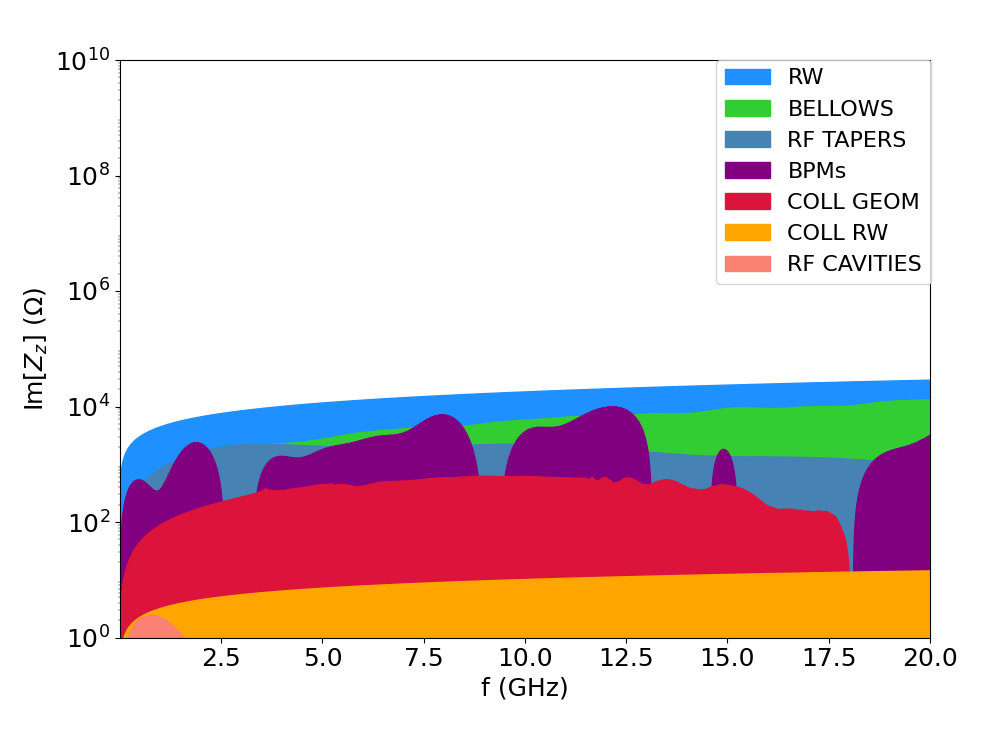

In [26]:
%matplotlib ipympl

plt.close('all')
fig, ax = plt.subplots(figsize=(10, 7.5)) 

ax.set_xlabel('f (GHz)')
ax.set_ylabel(r'Im[$Z_{z}$] ($\Omega$)')

ax.fill_between(frequency, Z_rw[:, 1], color='dodgerblue', alpha=1, label='RW pipe')
ax.fill_between(frequency, Z_bel[:, 1], color='limegreen', alpha=1, label='Bellows')
#ax.fill_between(frequency, Z_bpm[:, 1], color='purple', alpha=1, label='BPMs')
ax.fill_between(frequency, Z_RF_tap[:, 1], color='steelblue', alpha=1, label='RF tapers')
ax.fill_between(frequency, Z_bpm[:, 1], color='purple', alpha=1, label='BPMs')
ax.fill_between(frequency, Z_coll_geom[:, 1], color='crimson', alpha=1, label='Coll. geom.')
ax.fill_between(frequency, Z_coll_rw[:, 1], color='orange', alpha=1, label='Coll. RW')
ax.fill_between(frequency, Z_cav[:, 1], color='salmon', alpha=1, label='RF cavities')

legend_patches = [
    mpatches.Patch(color='dodgerblue', label='RW'),
    mpatches.Patch(color='limegreen', label='BELLOWS'),
    mpatches.Patch(color='steelblue', label='RF TAPERS'),
    mpatches.Patch(color='purple', label='BPMs'),
    mpatches.Patch(color='crimson', label='COLL GEOM'),
    mpatches.Patch(color='orange', label='COLL RW'),
    mpatches.Patch(color='salmon', label='RF CAVITIES')
]


ax.legend(handles=legend_patches, loc='upper right', bbox_to_anchor=(1.015, 1.02))

ax.set_xlim(1e-3, 20)
ax.set_ylim(1e-0, 1e10)
ax.set_yscale('log')
ax.set_xscale('linear')

ax.yaxis.set_major_locator(LogLocator(base=10.0, subs=(1.0,), numticks=8))
ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10)*0.1, numticks=40)) 
ax.tick_params(axis='y', which='minor', length=1.5, width=0.3)

fig.subplots_adjust(left=0.12, right=0.93, bottom=0.15, top=0.92)
plt.savefig(image_folder / "Z_long_Im_log_area.jpg", dpi=300, bbox_inches='tight')


## Elements contribution:  Re[$Z_{y}$] ($\Omega$/m)

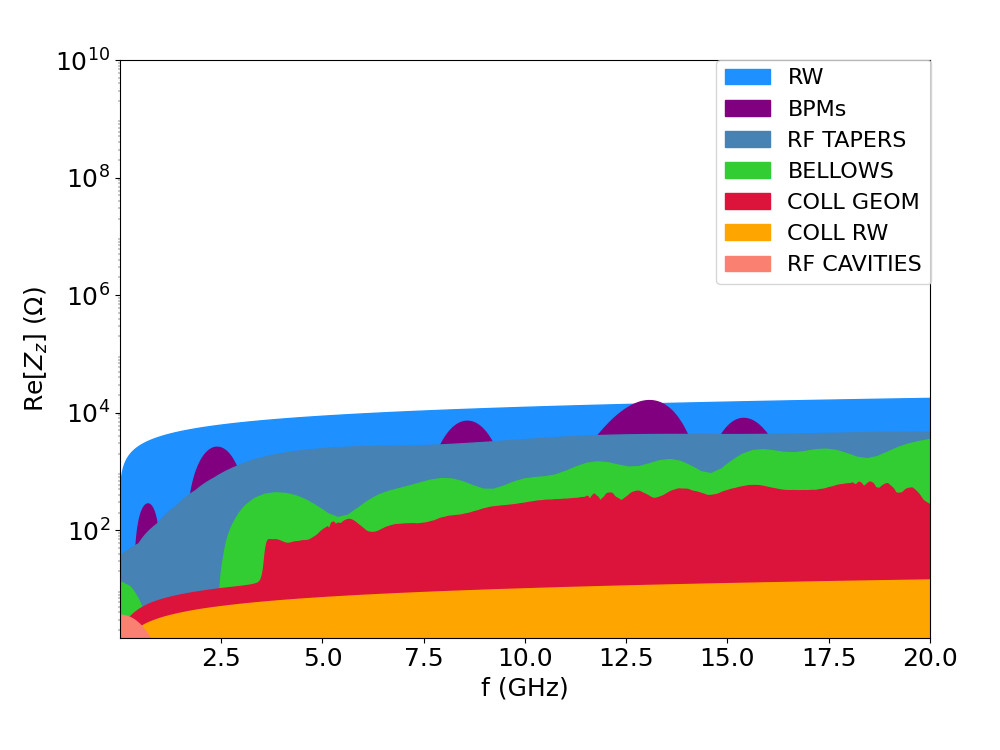

In [27]:
%matplotlib ipympl

plt.close('all')
fig, ax = plt.subplots(figsize=(10, 7.5)) 

ax.set_xlabel('f (GHz)')
ax.set_ylabel(r'Re[$Z_{z}$] ($\Omega$)')

ax.fill_between(frequency, Z_rw[:, 0], color='dodgerblue', alpha=1, label='RW pipe')
ax.fill_between(frequency, Z_bpm[:, 0], color='purple', alpha=1, label='BPMs')
ax.fill_between(frequency, Z_RF_tap[:, 0], color='steelblue', alpha=1, label='RF tapers')
ax.fill_between(frequency, Z_bel[:, 0], color='limegreen', alpha=1, label='Bellows')
ax.fill_between(frequency, Z_coll_geom[:, 0], color='crimson', alpha=1, label='Coll. geom.')
ax.fill_between(frequency, Z_coll_rw[:, 0], color='orange', alpha=1, label='Coll. RW')
ax.fill_between(frequency, Z_cav[:, 0], color='salmon', alpha=1, label='RF cavities')

legend_patches = [
    mpatches.Patch(color='dodgerblue', label='RW'),
    mpatches.Patch(color='purple', label='BPMs'),
    mpatches.Patch(color='steelblue', label='RF TAPERS'),
    mpatches.Patch(color='limegreen', label='BELLOWS'),
    mpatches.Patch(color='crimson', label='COLL GEOM'),
    mpatches.Patch(color='orange', label='COLL RW'),
    mpatches.Patch(color='salmon', label='RF CAVITIES')
]

ax.legend(handles=legend_patches, loc='upper right', bbox_to_anchor=(1.015, 1.02))

ax.set_xlim(1e-3, 20)
ax.set_ylim(1.5, 1e10)
ax.set_yscale('log')

ax.yaxis.set_major_locator(LogLocator(base=10.0, subs=(1.0,), numticks=8))
ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10)*0.1, numticks=40)) 
ax.tick_params(axis='y', which='minor', length=1.5, width=0.3)

fig.subplots_adjust(left=0.12, right=0.93, bottom=0.15, top=0.92)
plt.savefig(image_folder / "Z_long_Re_log_area.jpg", dpi=300, bbox_inches='tight')


## Total contribution: $Z^{tot}_{z}$ ($\Omega$)

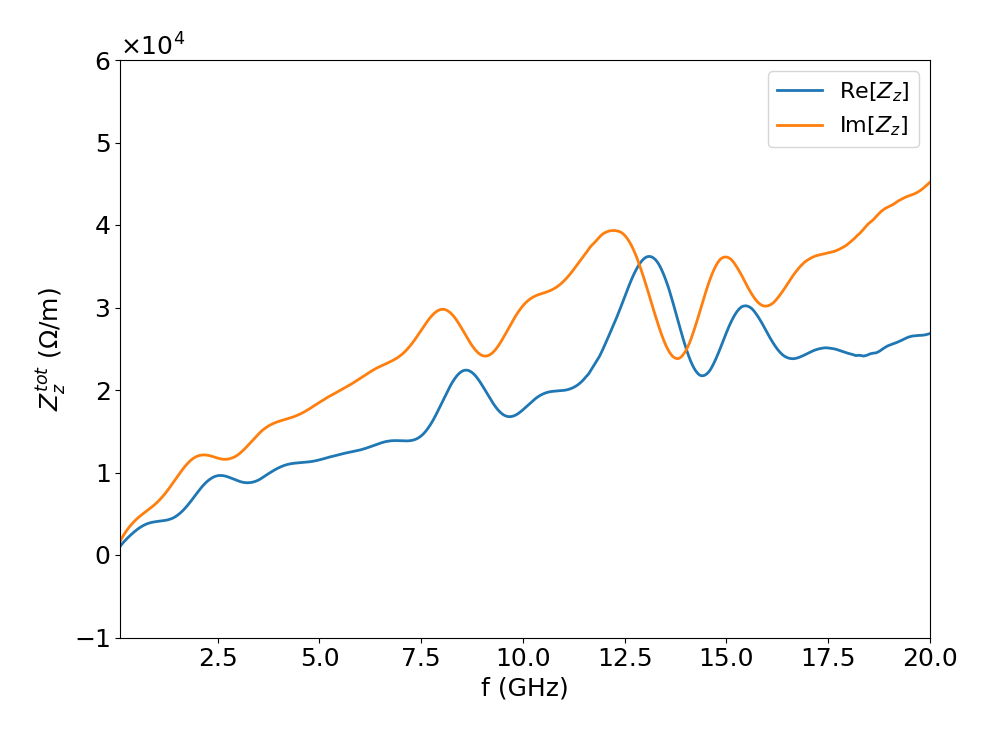

In [29]:
%matplotlib ipympl

plt.close('all')
fig, ax = plt.subplots(figsize=(10, 7.5)) 

ax.set_xlabel('f (GHz)')
ax.set_ylabel(r'$Z^{tot}_{z}$ ($\Omega$/m)')

plt.plot(frequency,Z_tot[:,0],linewidth=2,label=r'Re[$Z_{z}$]')
plt.plot(frequency,Z_tot[:,1],linewidth=2,label=r'Im[$Z_{z}$]')

plt.xscale('linear')
plt.yscale('linear')

plt.xlim(1e-1,20);
plt.ylim(-1e4,6e4)

ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
ax.yaxis.get_major_formatter().set_scientific(True)
ax.yaxis.get_major_formatter().set_powerlimits((-2, 2))

plt.legend(loc='upper right')

plt.subplots_adjust(left=0.12, right=0.93, bottom=0.15, top=0.92)
plt.savefig(image_folder / "Z_long_tot_lin.jpg", dpi=300, bbox_inches='tight')

### Export $Z^{tot}_{z}$ ($\Omega$/m)

In [30]:
head='f (GHz)        Re[Z] (Ohm)     Im[Z] (Ohm)'
np.savetxt(output_folder / "impedance_long.txt", list(zip(frequency,Z_tot[:,0],Z_tot[:,1])),
                                     fmt='%.6e',header=head,delimiter='    ')


head='f (GHz)        Re[Z] (Ohm)     Im[Z] (Ohm)'
np.savetxt(output_folder / "coll_rw_long_Z.txt", list(zip(frequency,Z_coll_rw[:,0],Z_coll_rw[:,1])),
                                     fmt='%.6e',header=head,delimiter='    ')

head='f (GHz)        Re[Z] (Ohm)     Im[Z] (Ohm)'
np.savetxt(output_folder / "coll_geom_long_Z.txt", list(zip(frequency,Z_coll_geom[:,0],Z_coll_geom[:,1])),
                                     fmt='%.6e',header=head,delimiter='    ')